<a href="https://colab.research.google.com/github/Ede-Rojin-Delibas/Machine-Learning/blob/master/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
customers = pd.read_csv("/content/olist_customers_dataset.csv")
orders = pd.read_csv("/content/olist_orders_dataset.csv")
order_items = pd.read_csv("/content/olist_order_items_dataset.csv")
products = pd.read_csv("/content/olist_products_dataset.csv")
payments = pd.read_csv("/content/olist_order_payments_dataset.csv")
reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")
category = pd.read_csv("/content/product_category_name_translation.csv")

In [ ]:
# tarihleri datetime yap
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# duplicate kontrol
print(orders.duplicated().sum())
print(order_items.duplicated().sum())

0
0


In [ ]:
df = pd.merge(order_items, orders, on="order_id", how="left")

print(df.shape)
df.head()

(112650, 14)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00


In [ ]:
df = pd.merge(df, products, on="product_id", how="left")

In [ ]:
df = pd.merge(df, category, on="product_category_name", how="left")

In [ ]:
df = pd.merge(df, customers, on="customer_id", how="left")

In [ ]:
payments_agg = payments.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_type": lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
}).reset_index()
df = pd.merge(df, payments_agg, on="order_id", how="left")

In [ ]:
reviews_agg = reviews.groupby("order_id").agg({
    "review_score": "mean"
}).reset_index()

df = pd.merge(df, reviews_agg, on="order_id", how="left")

In [ ]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,9.0,14.0,cool_stuff,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,72.19,credit_card,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,30.0,40.0,pet_shop,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,259.83,credit_card,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,13.0,33.0,furniture_decor,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,216.87,credit_card,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,10.0,15.0,perfumery,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,25.78,credit_card,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,40.0,30.0,garden_tools,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,218.04,credit_card,5.0


In [ ]:
df.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
customer_id,0
order_status,0
order_purchase_timestamp,0


In [ ]:
df.shape

(112650, 30)

In [ ]:
df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,9.0,14.0,cool_stuff,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,72.19,credit_card,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,30.0,40.0,pet_shop,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,259.83,credit_card,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,13.0,33.0,furniture_decor,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,216.87,credit_card,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,10.0,15.0,perfumery,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,25.78,credit_card,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,40.0,30.0,garden_tools,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,218.04,credit_card,5.0


In [ ]:
df.tail()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,review_score
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,15.0,40.0,housewares,0c9aeda10a71f369396d0c04dce13a64,65077,sao luis,MA,343.40,boleto,5.0
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,26.0,38.0,computers_accessories,0da9fe112eae0c74d3ba1fe16de0988b,81690,curitiba,PR,386.53,boleto,5.0
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,24.0,19.0,sports_leisure,cd79b407828f02fdbba457111c38e4c4,4039,sao paulo,SP,116.85,credit_card,5.0
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,20.0,20.0,computers_accessories,eb803377c9315b564bdedad672039306,13289,vinhedo,SP,64.71,credit_card,5.0
112649,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79,96d649da0cc4ff33bb408b199d4c7dcf,delivered,2018-06-09 17:00:18,...,3.0,19.0,bed_bath_table,cd76a00d8e3ca5e6ab9ed9ecb6667ac4,18605,botucatu,SP,55.79,credit_card,5.0


In [ ]:
df.sample(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,review_score
66217,975cb77712bd0680ba72f72f842db285,1,c8181e8e724bc31ef26d58c63f9898f7,c0098efcf800861dcae589affca31408,2018-01-26 21:35:19,69.40,13.51,e39dc53b86f3f80d0d47279856748b30,delivered,2018-01-22 21:20:53,...,20.0,20.0,auto,535835e982913fdbc36acd896bc0ae8f,8561,poa,SP,82.91,credit_card,5.0
59598,87d003714879bdc9c2adfe35a47268a4,1,75d6b6963340c6063f7f4cfcccfe6a30,cc419e0650a3c5ba77189a1882b7556a,2017-12-15 02:54:32,56.99,15.15,99bfe4238b5b10a3e83b388a471e3568,delivered,2017-12-06 22:33:42,...,11.0,20.0,perfumery,5c4db35a49343bbb9d8e93fd53ce6f7a,88930,turvo,SC,72.14,boleto,1.0
13668,1f195e1a5568ef0f4153d95a671a0f91,1,df3a82b424a1bb351c314547f6644066,4e922959ae960d389249c378d1c939f5,2018-01-25 03:38:49,65.00,15.20,b099cf5685910b720ea73ddc4ec9b4c5,delivered,2018-01-15 16:26:53,...,10.0,20.0,cool_stuff,e56faf66759bdbea23980e970e77cf1b,88119,sao jose,SC,80.20,boleto,1.0
92781,d26bc24224fef3d3b81a759802c26434,1,414c53fa9c5cc4a0390682aeb2e25ec1,002100f778ceb8431b7a1020ff7ab48f,2017-10-26 18:14:31,17.90,11.85,75e0bfb1c7701f6b53354ee10aa4268f,delivered,2017-10-22 18:07:06,...,30.0,20.0,furniture_decor,780e6b9df5eb8e08b92bf0402d3aa772,13604,araras,SP,29.75,credit_card,5.0
22129,3290d044feb4a9f2f4a195441b12ffe1,1,6c3effec7c8ddba466d4f03f982c7aa3,37515688008a7a40ac93e3b2e4ab203f,2017-09-11 12:44:01,19.90,11.85,751f6faa032664683bd9e96acb614b5e,delivered,2017-09-04 12:25:40,...,12.0,12.0,consoles_games,212588a002f9c07de6083ac91867b5df,17505,marilia,SP,31.75,credit_card,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  object        
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   customer_id                    112650 non-null  object        
 8   order_status                   112650 non-null  object        
 9   order_purchase_timestamp       112650 non-null  datetime64[ns]
 10  order_approved_at              112635 non-null  object        
 11  

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_item_id,112650.0,1.197834,1.0,1.0,1.0,1.0,21.0,0.705124
price,112650.0,120.653739,0.85,39.9,74.99,134.9,6735.0,183.633928
freight_value,112650.0,19.99032,0.0,13.08,16.26,21.15,409.68,15.806405
order_purchase_timestamp,112650,2018-01-01 00:09:48.464376576,2016-09-04 21:15:19,2017-09-13 19:17:04,2018-01-19 23:02:16,2018-05-04 17:30:36.750000128,2018-09-03 09:06:57,NaN
order_delivered_customer_date,110196,2018-01-14 13:25:24.023939328,2016-10-11 13:46:32,2017-09-26 20:09:44.500000,2018-02-02 20:57:23,2018-05-15 20:09:21.500000,2018-10-17 13:22:46,NaN
product_name_lenght,111047.0,48.775978,5.0,42.0,52.0,57.0,76.0,10.025581
product_description_lenght,111047.0,787.867029,4.0,348.0,603.0,987.0,3992.0,652.135608
product_photos_qty,111047.0,2.209713,1.0,1.0,1.0,3.0,20.0,1.721438
product_weight_g,112632.0,2093.672047,0.0,300.0,700.0,1800.0,40425.0,3751.596884
product_length_cm,112632.0,30.153669,7.0,18.0,25.0,38.0,105.0,16.153449


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527
seller_id,112650,3095,6560211a19b47992c3666cc44a7e94c0,2033
shipping_limit_date,112650,93318,2017-07-21 18:25:23,21
customer_id,112650,98666,fc3d1daec319d62d49bfb5e1f83123e9,21
order_status,112650,7,delivered,110197
order_approved_at,112635,90174,2018-02-24 03:20:27,23
order_delivered_carrier_date,111456,81017,2018-05-09 15:48:00,48
order_estimated_delivery_date,112650,450,2017-12-20 00:00:00,604
product_category_name,111047,73,cama_mesa_banho,11115


In [ ]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

In [ ]:
df["price"] = pd.to_numeric(df["price"], errors='coerce')

In [ ]:
df.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,object
price,float64
freight_value,float64
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]


In [ ]:
date_cols = [
    "shipping_limit_date",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
df[date_cols].dtypes

,0
shipping_limit_date,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [ ]:
int_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

for col in int_cols:
    df[col] = df[col].fillna(0).astype(int)

In [ ]:
cat_cols = [
    "order_status",
    "product_category_name_english",
    "customer_city",
    "customer_state",
    "payment_type"
]

for col in cat_cols:
    df[col] = df[col].astype("category")

In [ ]:
df["order_year"] = df["order_purchase_timestamp"].dt.year
df["order_month"] = df["order_purchase_timestamp"].dt.month
df["order_day"] = df["order_purchase_timestamp"].dt.day
df["order_weekday"] = df["order_purchase_timestamp"].dt.day_name()

In [ ]:
df["delivery_time"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

In [ ]:
df["Revenue"] = df["price"]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  datetime64[ns]
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   customer_id                    112650 non-null  object        
 8   order_status                   112650 non-null  category      
 9   order_purchase_timestamp       112650 non-null  datetime64[ns]
 10  order_approved_at              112635 non-null  datetime64[ns]
 11  

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
delivery_time,2454
order_delivered_customer_date,2454
product_category_name_english,1627
product_category_name,1603
order_delivered_carrier_date,1194
review_score,942
product_length_cm,18
product_weight_g,18
product_height_cm,18
product_width_cm,18


In [ ]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
delivery_time,2.178429
order_delivered_customer_date,2.178429
product_category_name_english,1.444296
product_category_name,1.422992
order_delivered_carrier_date,1.059920
review_score,0.836218
product_length_cm,0.015979
product_weight_g,0.015979
product_height_cm,0.015979
product_width_cm,0.015979


In [ ]:
df["delivery_time"] = df["delivery_time"].fillna(
    df["delivery_time"].median()
)

In [ ]:
df["order_delivered_customer_date"] = df["order_delivered_customer_date"].fillna(
    df["order_estimated_delivery_date"]
)

In [ ]:
if "Unknown" not in df["product_category_name_english"].cat.categories:
    df["product_category_name_english"] = df["product_category_name_english"].cat.add_categories("Unknown")
df["product_category_name_english"] = df["product_category_name_english"].fillna("Unknown")

In [ ]:
df["order_delivered_carrier_date"] = df["order_delivered_carrier_date"].fillna(
    df["order_purchase_timestamp"]
)

In [ ]:
df["review_score"] = df["review_score"].fillna(
    df["review_score"].median()
)

In [ ]:
size_cols = [
    "product_length_cm",
    "product_weight_g",
    "product_height_cm",
    "product_width_cm"
]

for col in size_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df["order_approved_at"] = df["order_approved_at"].fillna(
    df["order_purchase_timestamp"]
)

In [ ]:
df["payment_type"] = df["payment_type"].cat.add_categories("Unknown")
df["payment_type"] = df["payment_type"].fillna("Unknown")

In [ ]:
df["payment_value"] = df["payment_value"].fillna(
    df["payment_value"].median()
)

In [ ]:
df.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
customer_id,0
order_status,0
order_purchase_timestamp,0


In [ ]:
df[df["product_category_name_english"] == "Unknown"]["Revenue"].sum()

np.float64(185049.76)

In [ ]:
df["product_category_name_english"].isnull().sum()

np.int64(0)

In [ ]:
(df["product_category_name_english"] == "").sum()

np.int64(0)

In [ ]:
(df["product_category_name_english"] == "nan").sum()

np.int64(0)

In [ ]:
df["product_category_name_english"] = df["product_category_name_english"].astype(str)

In [ ]:
df["product_category_name_english"] = df["product_category_name_english"].replace(
    ["nan", "", "None"], "Unknown"
)

df["product_category_name_english"] = df["product_category_name_english"].fillna("Unknown")

In [ ]:
df["product_category_name_english"] = df["product_category_name_english"].astype("category")

In [ ]:
df["product_category_name_english"].isnull().sum()

np.int64(0)

In [ ]:
df["product_category_name_english"].value_counts().head(10)

,count
product_category_name_english,
bed_bath_table,11115
health_beauty,9670
sports_leisure,8641
furniture_decor,8334
computers_accessories,7827
housewares,6964
watches_gifts,5991
telephony,4545
garden_tools,4347


<Axes: xlabel='price'>

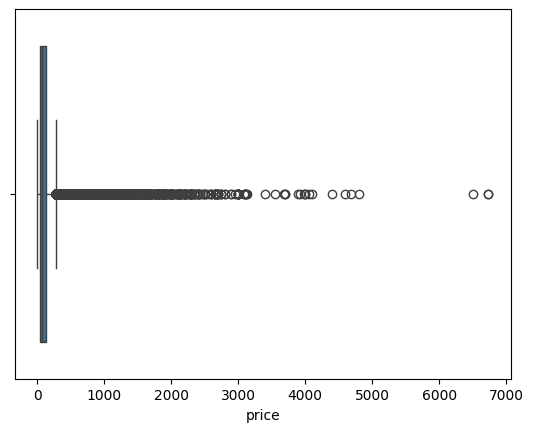

In [ ]:
import seaborn as sns
sns.boxplot(x=df["price"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  datetime64[ns]
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   customer_id                    112650 non-null  object        
 8   order_status                   112650 non-null  category      
 9   order_purchase_timestamp       112650 non-null  datetime64[ns]
 10  order_approved_at              112650 non-null  datetime64[ns]
 11  

In [ ]:
df.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
customer_id,0
order_status,0
order_purchase_timestamp,0


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_item_id,112650.0,1.197834,1.0,1.0,1.0,1.0,21.0,0.705124
shipping_limit_date,112650,2018-01-07 15:36:52.192685312,2016-09-19 00:15:34,2017-09-20 20:57:27.500000,2018-01-26 13:59:35,2018-05-10 14:34:00.750000128,2020-04-09 22:35:08,NaN
price,112650.0,120.653739,0.85,39.9,74.99,134.9,6735.0,183.633928
freight_value,112650.0,19.99032,0.0,13.08,16.26,21.15,409.68,15.806405
order_purchase_timestamp,112650,2018-01-01 00:09:48.464376576,2016-09-04 21:15:19,2017-09-13 19:17:04,2018-01-19 23:02:16,2018-05-04 17:30:36.750000128,2018-09-03 09:06:57,NaN
order_approved_at,112650,2018-01-01 10:44:28.697612544,2016-09-15 12:16:38,2017-09-14 02:57:55.249999872,2018-01-20 12:50:58,2018-05-05 03:06:27.500000,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,112650,2018-01-04 06:17:07.319716096,2016-09-05 00:15:34,2017-09-15 21:27:38,2018-01-23 23:37:38.500000,2018-05-08 11:41:30,2018-09-11 19:48:28,NaN
order_delivered_customer_date,112650,2018-01-13 18:08:02.248930048,2016-10-11 13:46:32,2017-09-25 20:13:49.500000,2018-02-02 15:18:04.500000,2018-05-15 17:36:15.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,112650,2018-01-24 20:12:15.531291392,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
product_name_lenght,112650.0,48.0819,0.0,42.0,51.0,57.0,76.0,11.508904


In [ ]:
def quick_check(df):
    print("Shape:", df.shape)
    print("\nTypes:\n", df.dtypes)
    print("\nMissing:\n", df.isnull().sum())
    print("\nUnique:\n", df.nunique())
    print("\nHead:\n", df.head())

In [ ]:
quick_check(df)

Shape: (112650, 36)

Types:
 order_id                                 object
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
customer_id                              object
order_status                           category
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
product_category_name                    object
product_name_lenght                       int64
product_description_lenght                int64
product_photos_qty                        int64
product_weight_g                        float64
product_length_cm                       float64
product_hei

In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (112650, 36)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_value', 'payment_type', 'review_score', 'order_year', 'order_month', 'order_day', 'order_weekday', 'delivery_time', 'Revenue']


In [ ]:
df[["order_id", "order_item_id"]].head()

,order_id,order_item_id
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1


In [ ]:
df[["price", "freight_value", "payment_value", "Revenue"]].describe().T

,count,mean,std,min,25%,50%,75%,max
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.9000,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.1500,409.68
payment_value,112650.0,180.279432,272.845620,9.59,65.67,114.44,195.3825,13664.08
Revenue,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.9000,6735.00


In [ ]:
cat_cols = df.select_dtypes(include="category").columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head())


order_status
order_status
delivered     110197
shipped         1185
canceled         542
invoiced         359
processing       357
Name: count, dtype: int64

product_category_name_english
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
Name: count, dtype: int64

customer_city
customer_city
sao paulo         17808
rio de janeiro     7837
belo horizonte     3144
brasilia           2392
curitiba           1751
Name: count, dtype: int64

customer_state
customer_state
SP    47449
RJ    14579
MG    13129
RS     6235
PR     5740
Name: count, dtype: int64

payment_type
payment_type
credit_card    86017
boleto         22867
voucher         2074
debit_card      1689
Unknown            3
Name: count, dtype: int64


In [ ]:
#zaman aralığı analizi
print("Min date:", df["order_purchase_timestamp"].min())
print("Max date:", df["order_purchase_timestamp"].max())

Min date: 2016-09-04 21:15:19
Max date: 2018-09-03 09:06:57


In [ ]:
df["order_year"].value_counts()

,count
order_year,
2018,61416
2017,50864
2016,370


In [ ]:
#TEMEL KPI’LARI HESAPLA
total_revenue = df["Revenue"].sum()
avg_revenue = df["Revenue"].mean()
total_orders = df["order_id"].nunique()
total_customers = df["customer_unique_id"].nunique()

print("Total Revenue:", total_revenue)
print("Average Revenue per Item:", avg_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Revenue: 13591643.700000003
Average Revenue per Item: 120.65373901464716
Total Orders: 98666
Total Customers: 95420


In [ ]:
#ORDER vs CUSTOMER ANALİZİ
orders_per_customer = df.groupby("customer_unique_id")["order_id"].nunique()

orders_per_customer.describe()

,order_id
count,95420.000000
mean,1.034018
std,0.211234
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,16.000000


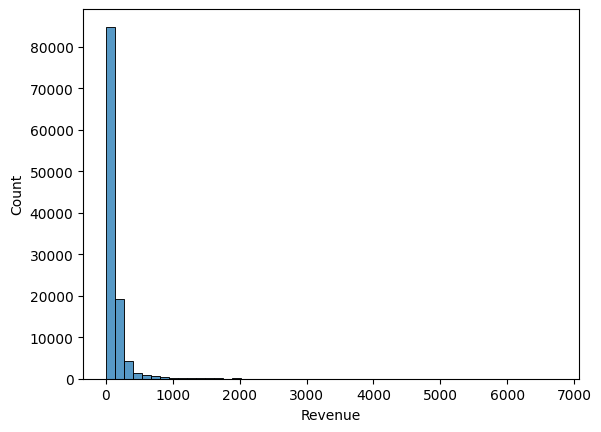

In [ ]:
#REVENUE DAĞILIMI
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Revenue"], bins=50)
plt.show()

In [ ]:
df["delivery_time"].describe()

,delivery_time
count,112650.000000
mean,11.963986
std,9.352534
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


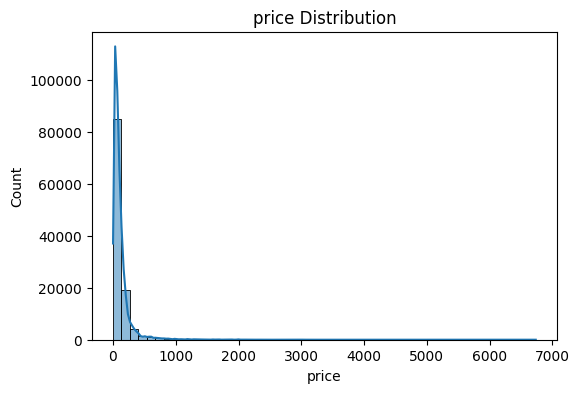

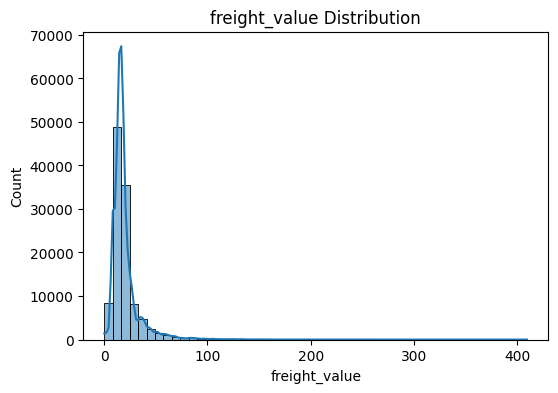

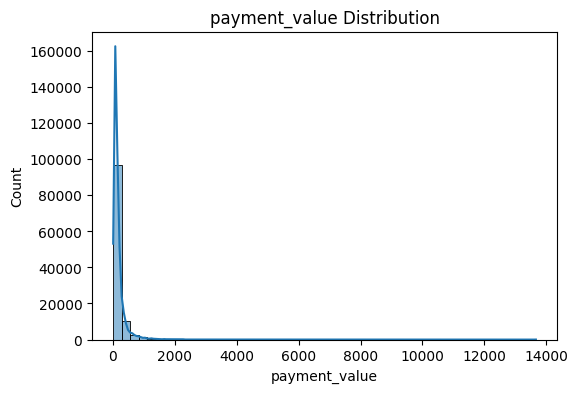

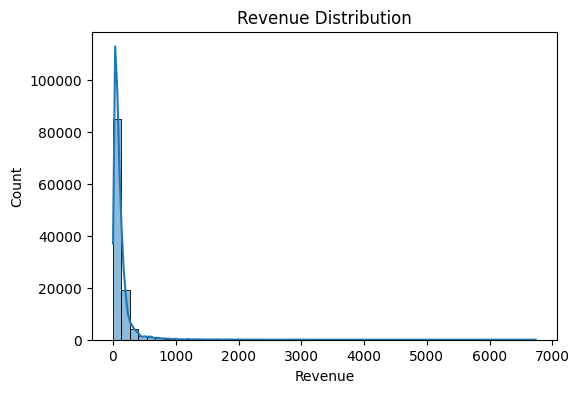

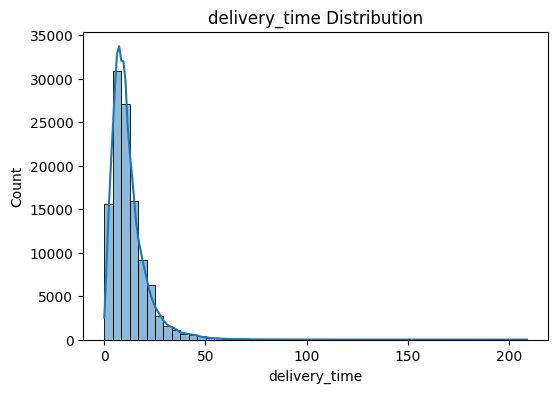

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["price", "freight_value", "payment_value", "Revenue", "delivery_time"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

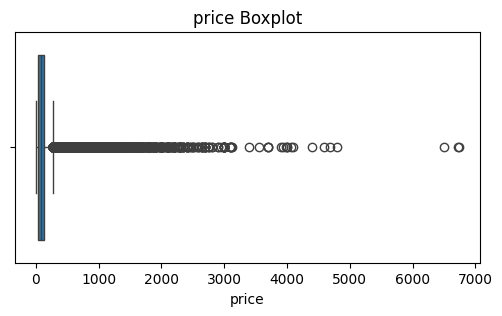

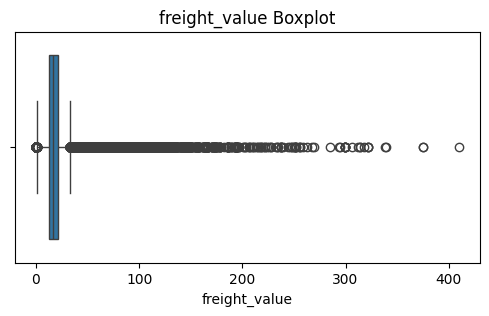

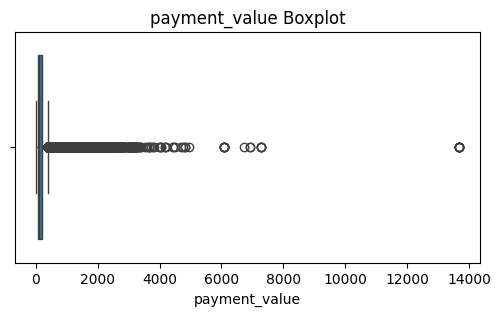

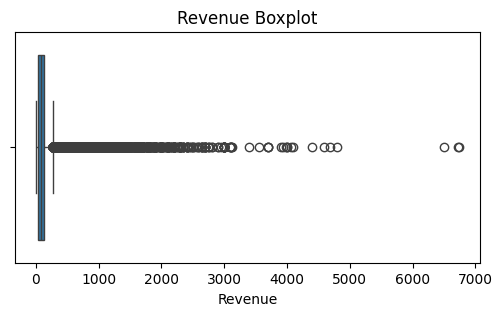

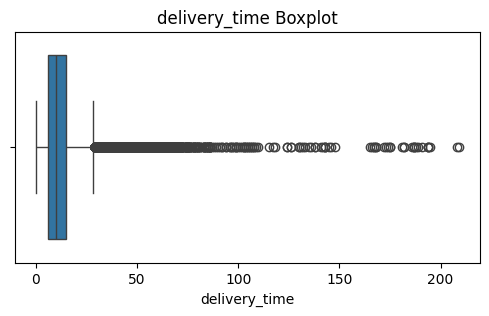

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

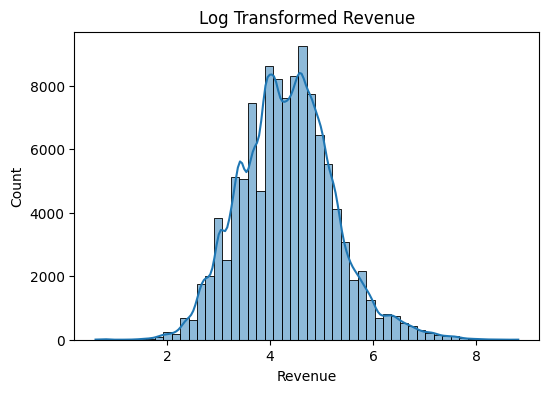

In [ ]:
import numpy as np

plt.figure(figsize=(6,4))
sns.histplot(np.log1p(df["Revenue"]), bins=50, kde=True)
plt.title("Log Transformed Revenue")
plt.show()

In [ ]:
cat_cols = [
    "product_category_name_english",
    "payment_type",
    "order_status",
    "customer_state"
]

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


product_category_name_english
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64

payment_type
payment_type
credit_card    86017
boleto         22867
voucher         2074
debit_card      1689
Unknown            3
Name: count, dtype: int64

order_status
order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

customer_state
customer_state
SP    47449
RJ    14579
MG    13129
RS     6235
PR     5740
SC     4176
BA     3799
DF     2406
GO     2333
ES     2256
Name: count, dtype: int64


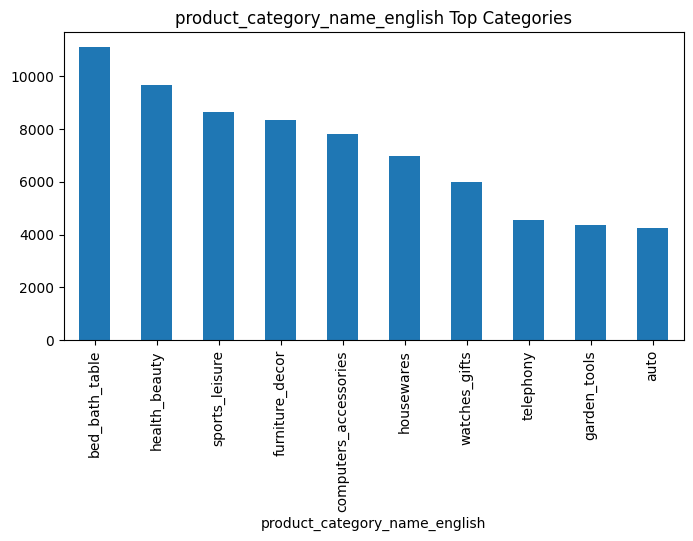

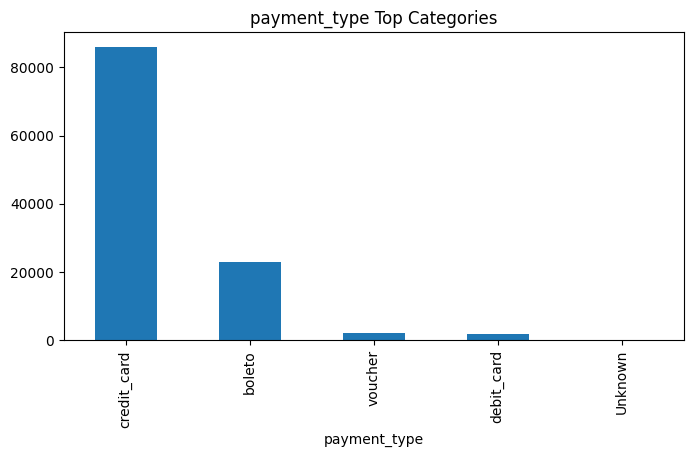

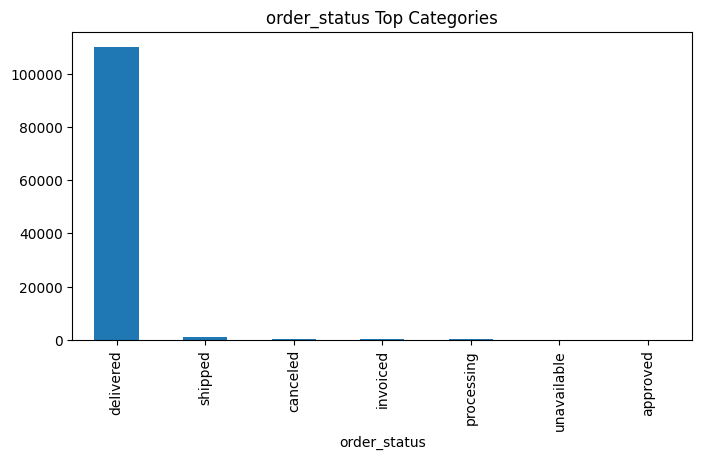

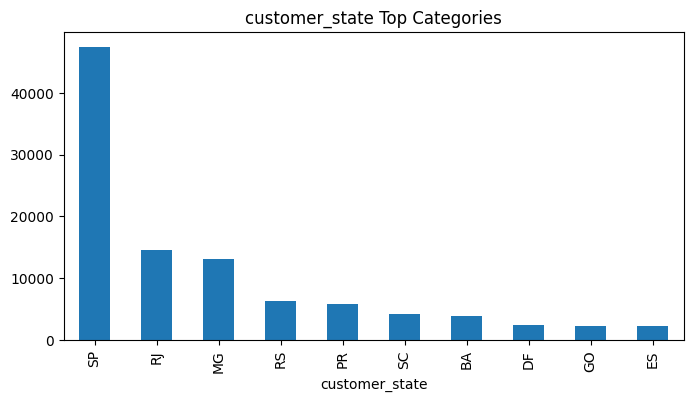

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"{col} Top Categories")
    plt.show()

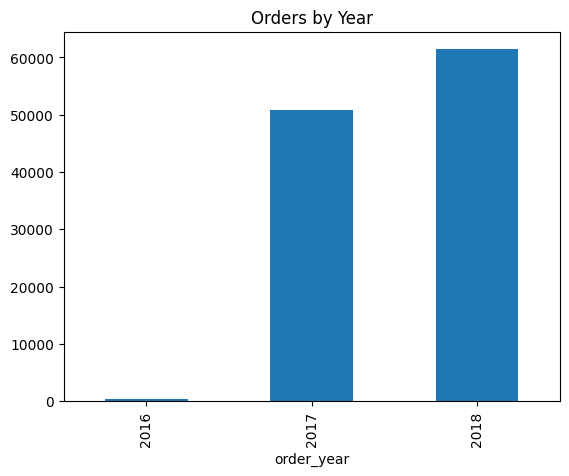

In [ ]:
#TIME-BASED ANALYSIS
df["order_year"].value_counts().sort_index().plot(kind='bar')
plt.title("Orders by Year")
plt.show()

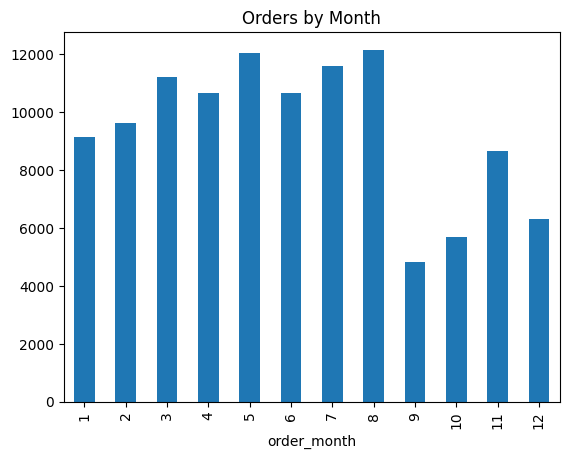

In [ ]:
df["order_month"].value_counts().sort_index().plot(kind='bar')
plt.title("Orders by Month")
plt.show()

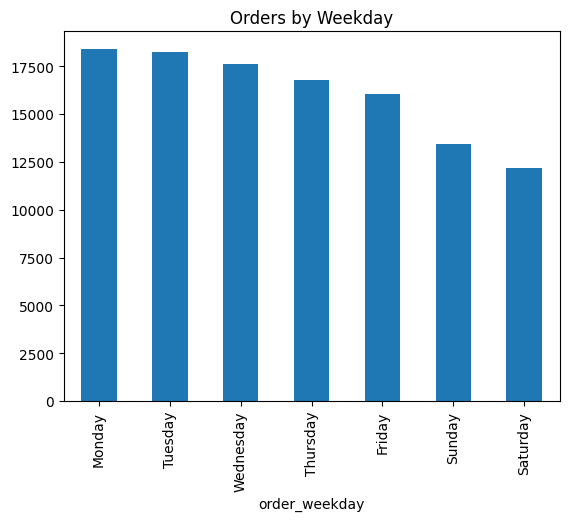

In [ ]:
df["order_weekday"].value_counts().plot(kind='bar')
plt.title("Orders by Weekday")
plt.show()

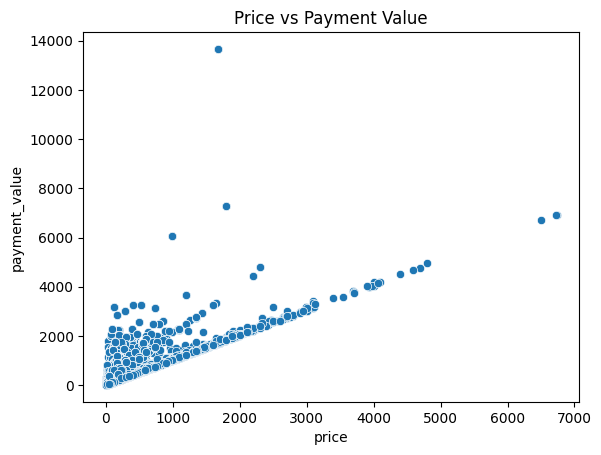

In [ ]:
#Bivariate analysis
#Numeric vs Numeric Relations
sns.scatterplot(x=df["price"], y=df["payment_value"])
plt.title("Price vs Payment Value")
plt.show()

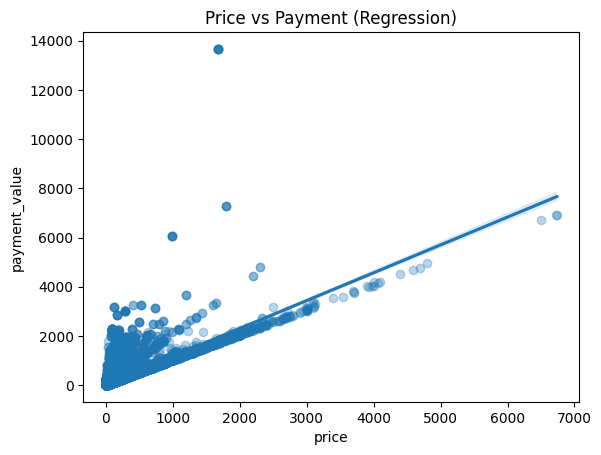

In [ ]:
sns.regplot(x=df["price"], y=df["payment_value"], scatter_kws={"alpha":0.3})
plt.title("Price vs Payment (Regression)")
plt.show()

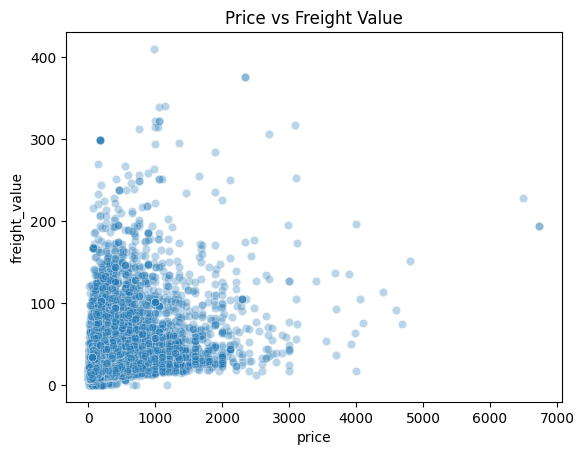

In [ ]:
#price vs freight value
sns.scatterplot(x="price", y="freight_value", data=df, alpha=0.3)
plt.title("Price vs Freight Value")
plt.show()

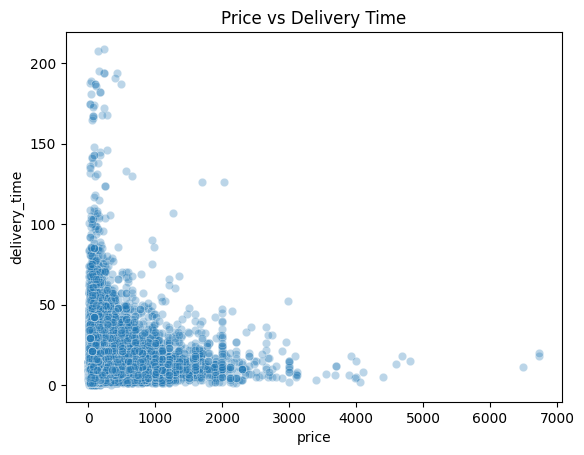

In [ ]:
#price-delivery time
sns.scatterplot(x="price", y="delivery_time", data=df, alpha=0.3)
plt.title("Price vs Delivery Time")
plt.show()

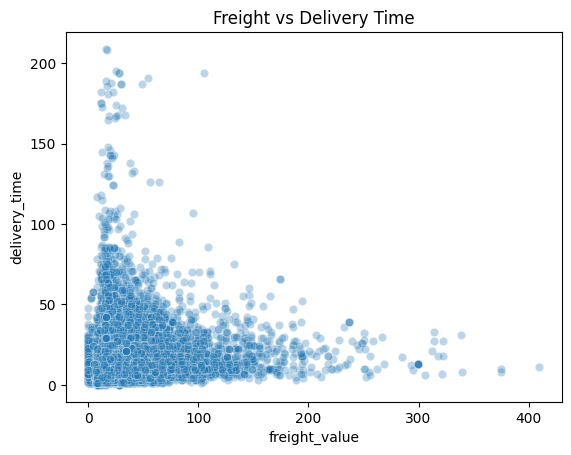

In [ ]:
#freight value vs delivery time
sns.scatterplot(x="freight_value", y="delivery_time", data=df, alpha=0.3)
plt.title("Freight vs Delivery Time")
plt.show()

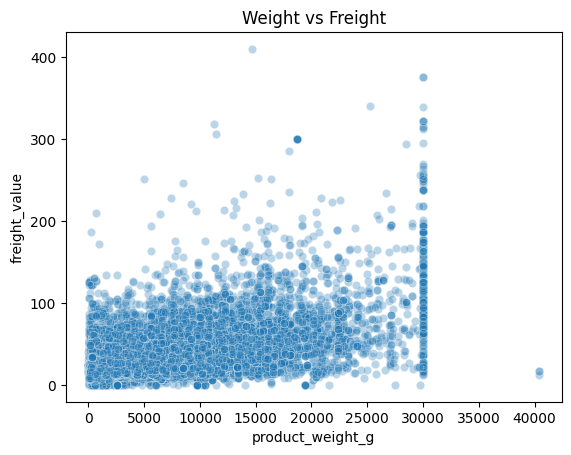

In [ ]:
#product weight vs freight
sns.scatterplot(x="product_weight_g", y="freight_value", data=df, alpha=0.3)
plt.title("Weight vs Freight")
plt.show()

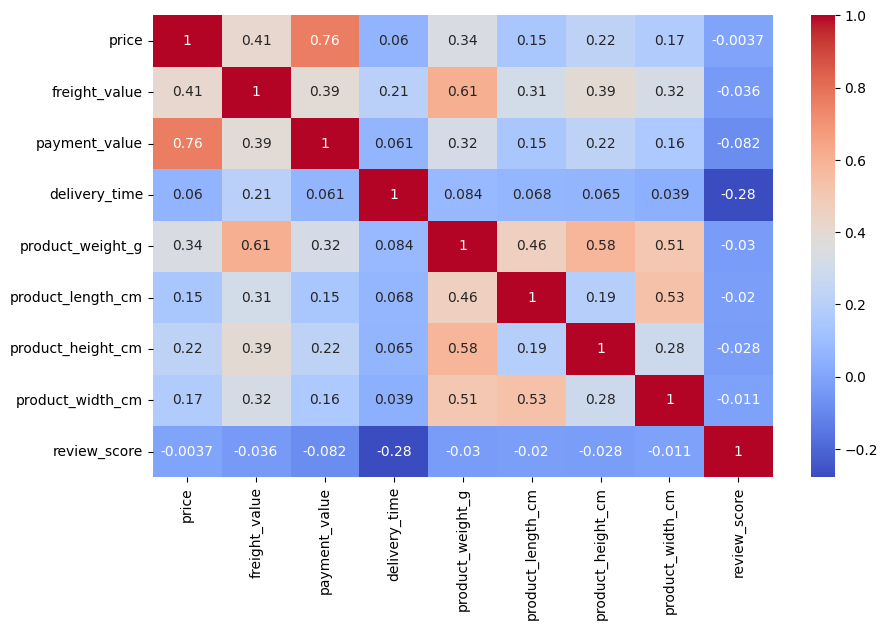

In [ ]:
#CORRELATION MATRIX
num_cols = [
    "price", "freight_value", "payment_value",
    "delivery_time", "product_weight_g",
    "product_length_cm", "product_height_cm",
    "product_width_cm", "review_score"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

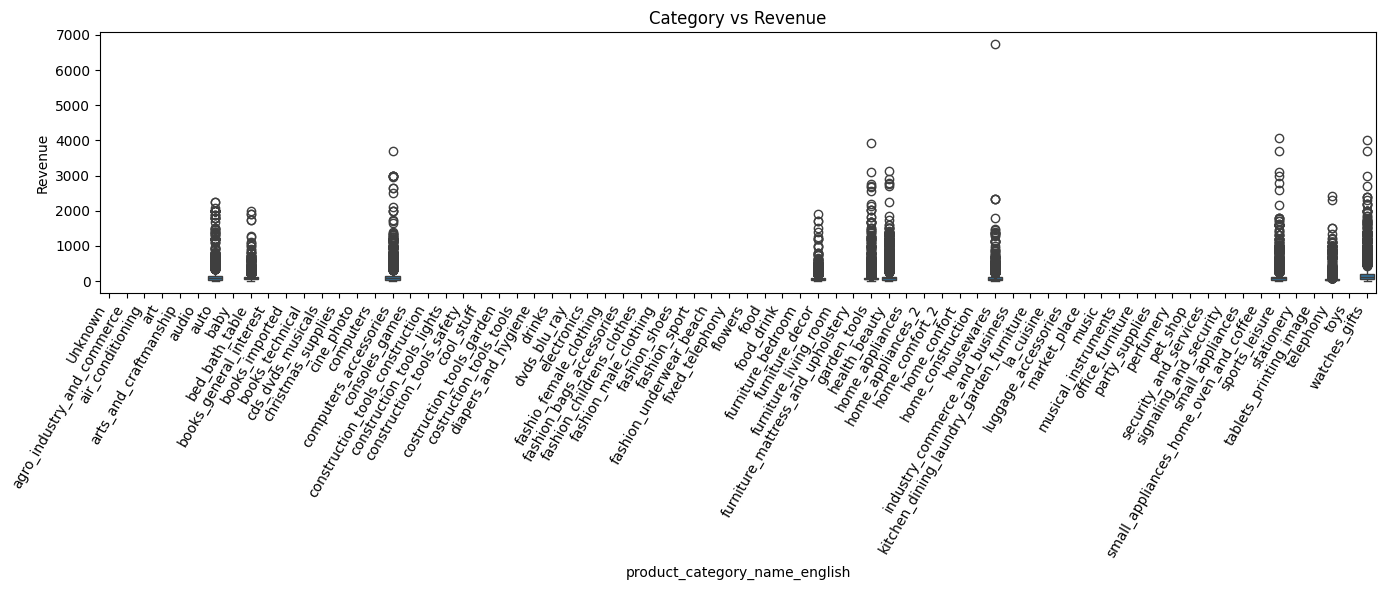

In [ ]:
#Category vs Category
#category vs revenue
top_categories = df["product_category_name_english"].value_counts().head(10).index

plt.figure(figsize=(14,6))
sns.boxplot(
    x="product_category_name_english",
    y="Revenue",
    data=df[df["product_category_name_english"].isin(top_categories)]
)
plt.xticks(rotation=60, ha="right")
plt.title("Category vs Revenue")
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'payment_value', 'payment_type', 'review_score', 'order_year',
       'order_month', 'order_day', 'order_weekday', 'delivery_time',
       'Revenue'],
      dtype='object')

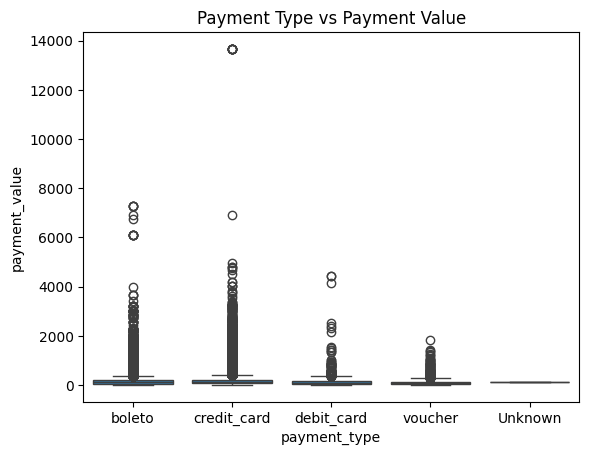

In [ ]:
#payment type vs payment value
sns.boxplot(x="payment_type", y="payment_value", data=df)
plt.title("Payment Type vs Payment Value")
plt.show()

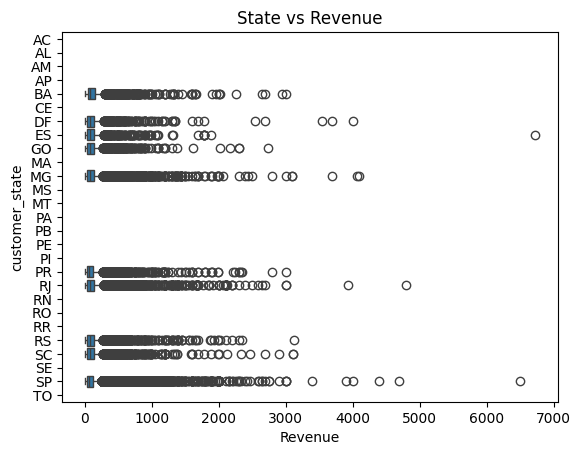

In [ ]:
#state vs revenue
top_states = df["customer_state"].value_counts().head(10).index

sns.boxplot(
    y="customer_state",
    x="Revenue",
    data=df[df["customer_state"].isin(top_states)]
)
plt.title("State vs Revenue")
plt.show()

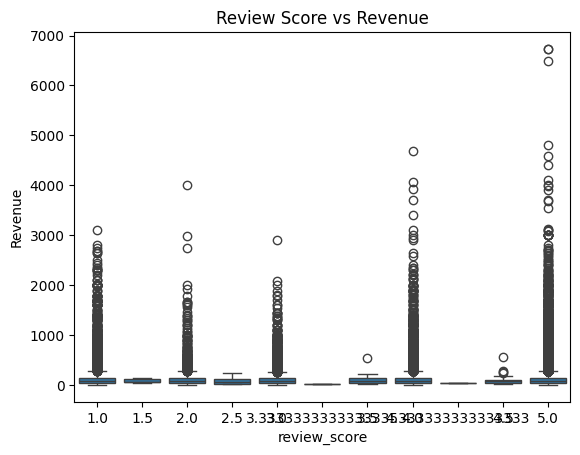

In [ ]:
#review score vs revenue
sns.boxplot(x="review_score", y="Revenue", data=df)
plt.title("Review Score vs Revenue")
plt.show()

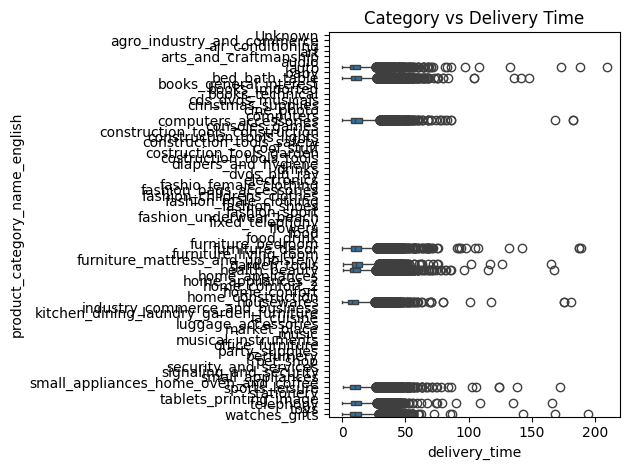

In [ ]:
#category vs delivery time
sns.boxplot(
    y="product_category_name_english",
    x="delivery_time",
    data=df[df["product_category_name_english"].isin(top_categories)]
)
plt.title("Category vs Delivery Time")
plt.tight_layout()
plt.show()

In [ ]:
#categorical vs categorical
pd.crosstab(df["payment_type"], df["order_status"])

order_status,approved,canceled,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,
boleto,0,96,22362,91,97,221,0
credit_card,3,433,84154,258,251,911,7
debit_card,0,6,1652,6,2,23,0
voucher,0,7,2026,4,7,30,0
Unknown,0,0,3,0,0,0,0


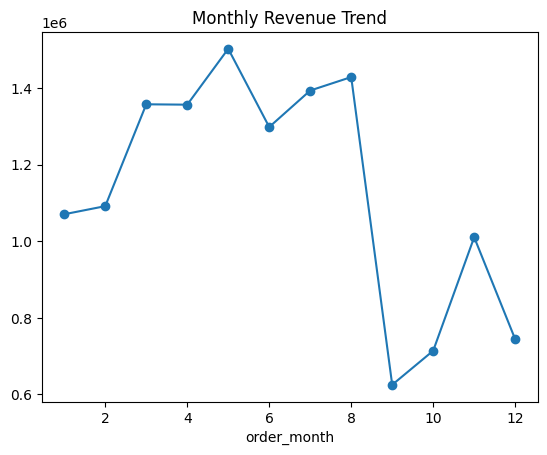

In [ ]:
#time vs target
#monthly revenue
monthly_sales = df.groupby("order_month")["Revenue"].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.show()

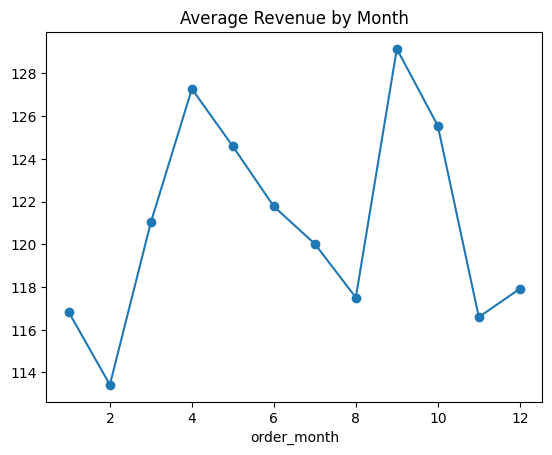

In [ ]:
df.groupby("order_month")["Revenue"].mean().plot(marker='o')
plt.title("Average Revenue by Month")
plt.show()

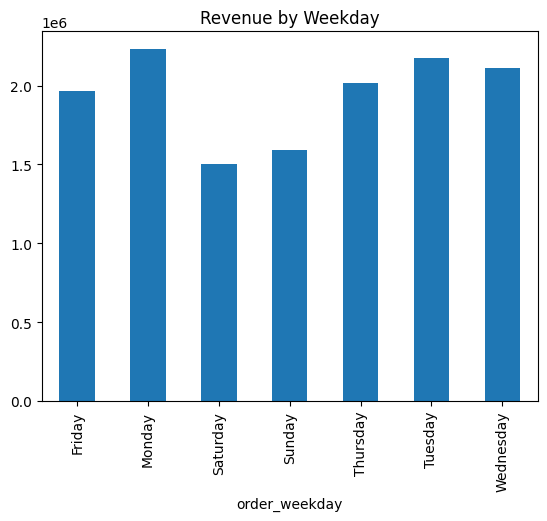

In [ ]:
#daily bases
df.groupby("order_weekday")["Revenue"].sum().plot(kind='bar')
plt.title("Revenue by Weekday")
plt.show()

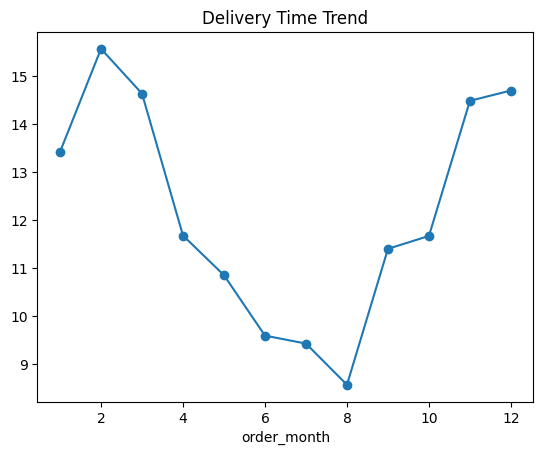

In [ ]:
#delivery time by month
df.groupby("order_month")["delivery_time"].mean().plot(marker='o')
plt.title("Delivery Time Trend")
plt.show()

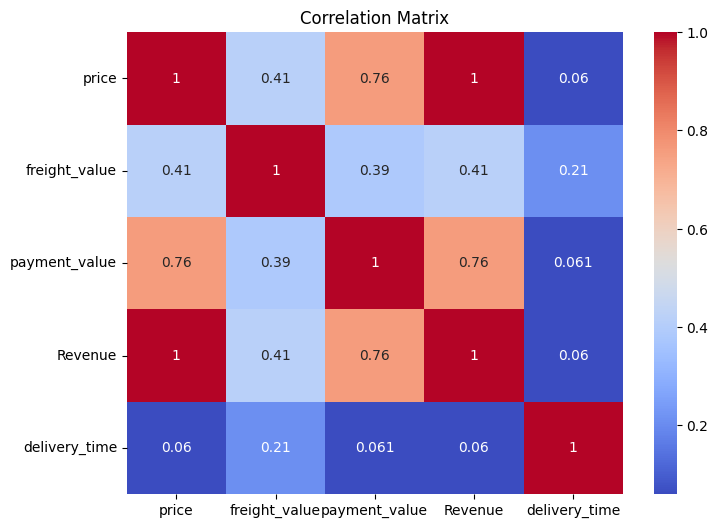

In [ ]:
#correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df[["price","freight_value","payment_value","Revenue","delivery_time"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

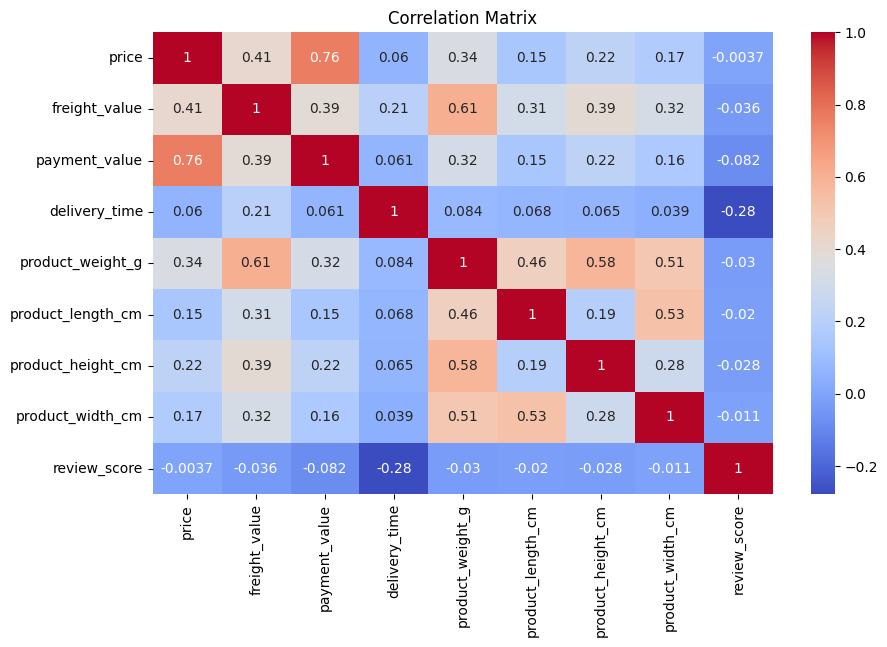

In [ ]:
#MULTIVARIATE ANALYSIS
num_cols = [
    "price", "freight_value", "payment_value",
    "delivery_time", "product_weight_g",
    "product_length_cm", "product_height_cm",
    "product_width_cm", "review_score"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

/tmp/ipykernel_4745/3850600841.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


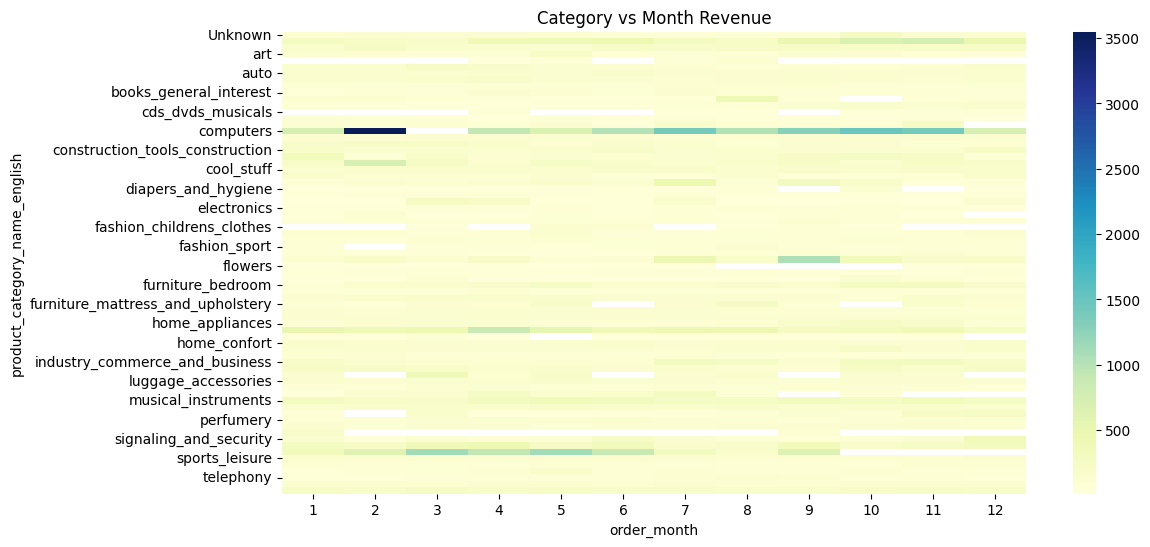

In [ ]:
pivot = df.pivot_table(
    values="Revenue",
    index="product_category_name_english",
    columns="order_month",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Category vs Month Revenue")
plt.show()

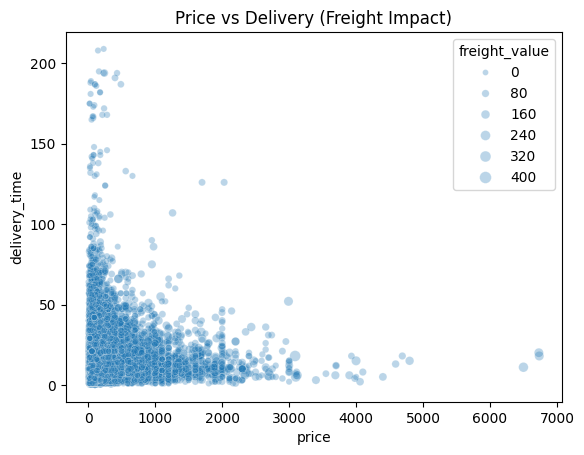

In [ ]:
sns.scatterplot(
    x="price",
    y="delivery_time",
    size="freight_value",
    data=df,
    alpha=0.3
)
plt.title("Price vs Delivery (Freight Impact)")
plt.show()

In [ ]:
#SEGMENT ANALYSIS
#customer total spend
customer_spend = df.groupby("customer_unique_id")["Revenue"].sum()

customer_spend.describe()

,Revenue
count,95420.000000
mean,142.440198
std,217.656355
min,0.850000
25%,47.900000
50%,89.900000
75%,155.000000
max,13440.000000


In [ ]:
df_customer = customer_spend.reset_index()

df_customer["segment"] = pd.qcut(
    df_customer["Revenue"],
    3,
    labels=["Low", "Medium", "High"]
)

In [ ]:
df_customer["segment"].value_counts()

,count
segment,
Low,31876
High,31797
Medium,31747


In [ ]:
#category segmentation
category_revenue = df.groupby("product_category_name_english")["Revenue"].sum().sort_values(ascending=False)

category_revenue.head(10)

/tmp/ipykernel_4745/561294873.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_revenue = df.groupby("product_category_name_english")["Revenue"].sum().sort_values(ascending=False)


,Revenue
product_category_name_english,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


In [ ]:
#delivery segment
df["delivery_segment"] = pd.cut(
    df["delivery_time"],
    bins=[0,3,7,15,30],
    labels=["Fast","Normal","Slow","Very Slow"]
)

In [ ]:
df["delivery_segment"].value_counts()

,count
delivery_segment,
Slow,47794
Normal,28774
Very Slow,21574
Fast,9931


In [ ]:
#payment segment
df.groupby("payment_type")["Revenue"].mean()

/tmp/ipykernel_4745/2042595998.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("payment_type")["Revenue"].mean()


,Revenue
payment_type,
boleto,104.584146
credit_card,125.998762
debit_card,108.721640
voucher,85.977194
Unknown,44.990000


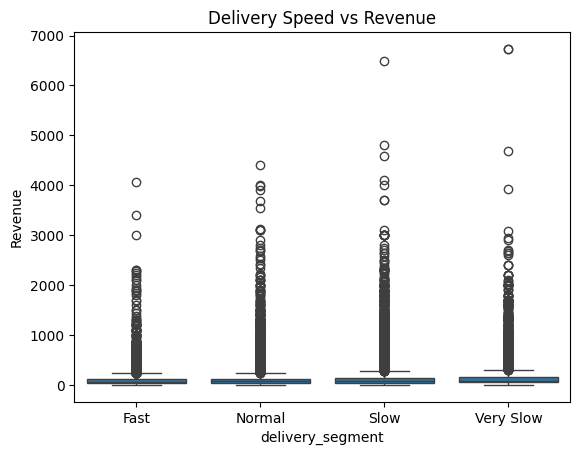

In [ ]:
## SEGMENT + METRİC
sns.boxplot(
    x="delivery_segment",
    y="Revenue",
    data=df
)
plt.title("Delivery Speed vs Revenue")
plt.show()

In [ ]:
#TREND ANALYSIS
monthly = df.groupby("order_month").agg({
    "Revenue": "sum",
    "order_id": "nunique",
    "customer_unique_id": "nunique",
    "delivery_time": "mean"
}).reset_index()

monthly

,order_month,Revenue,order_id,customer_unique_id,delivery_time
0,1,1070343.23,8009,7870,13.415366
1,2,1091481.73,8427,8243,15.561779
2,3,1357557.74,9829,9691,14.629848
3,4,1356574.98,9325,9235,11.676517
4,5,1502588.82,10513,10374,10.851090
5,6,1298162.91,9377,9269,9.594410
6,7,1393538.70,10242,10099,9.428904
7,8,1428658.01,10745,10615,8.571476
8,9,624814.05,4247,4174,11.399959
9,10,713727.09,4876,4806,11.668074


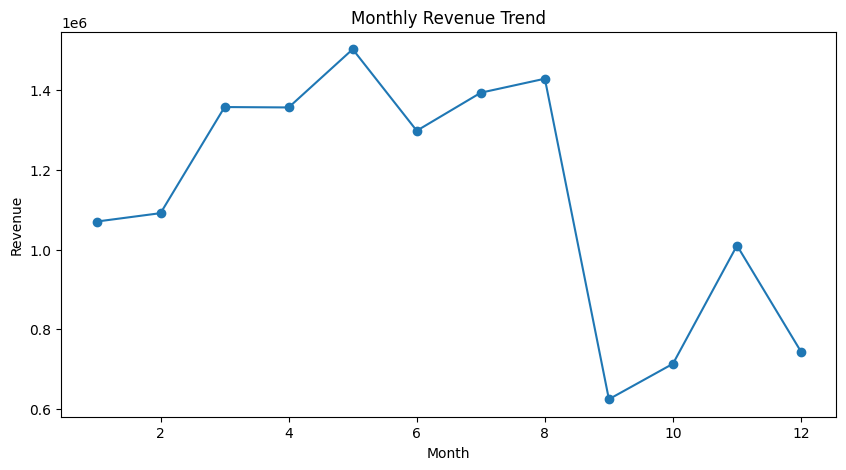

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly["order_month"], monthly["Revenue"], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

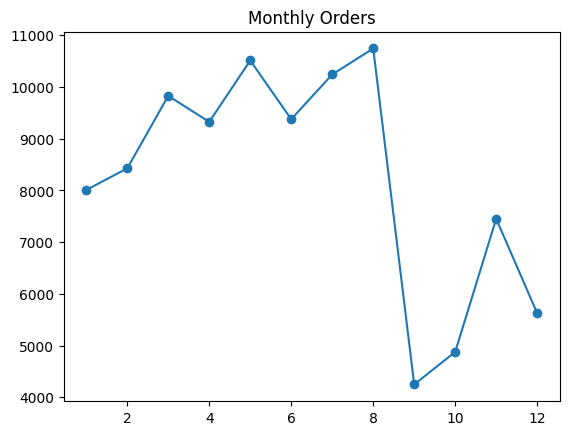

In [ ]:
plt.plot(monthly["order_month"], monthly["order_id"], marker='o')
plt.title("Monthly Orders")
plt.show()

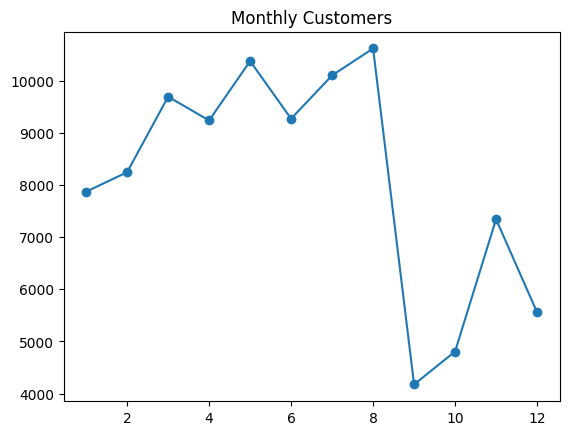

In [ ]:
plt.plot(monthly["order_month"], monthly["customer_unique_id"], marker='o')
plt.title("Monthly Customers")
plt.show()

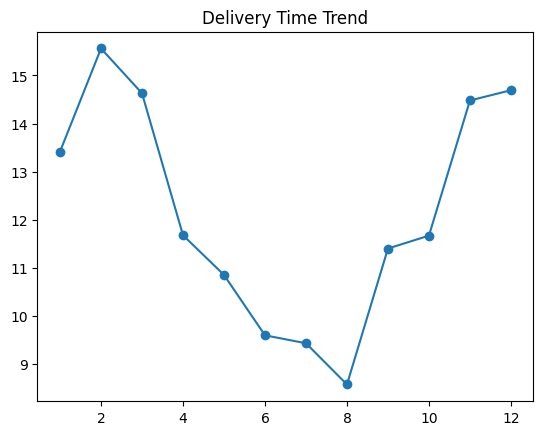

In [ ]:
plt.plot(monthly["order_month"], monthly["delivery_time"], marker='o')
plt.title("Delivery Time Trend")
plt.show()